# Data Visualization with Python

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("imigrantes_canada.csv")

In [4]:
df.head()

,País,Continente,Região,1980,1981,1982,1983,1984,1985,1986,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
0,Afeganistão,Ásia,Sul da Ásia,16,39,39,47,71,340,496,...,3436,3009,2652,2111,1746,1758,2203,2635,2004,58639
1,Albânia,Europa,Sul da Europa,1,0,0,0,0,0,1,...,1223,856,702,560,716,561,539,620,603,15699
2,Argélia,África,Norte da África,80,67,71,69,63,44,69,...,3626,4807,3623,4005,5393,4752,4325,3774,4331,69439
3,Samoa Americana,Oceânia,Polinésia,0,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,6
4,Andorra,Europa,Sul da Europa,0,0,0,0,0,0,2,...,0,1,1,0,0,0,0,1,1,15


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 38 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   País        195 non-null    object
 1   Continente  195 non-null    object
 2   Região      195 non-null    object
 3   1980        195 non-null    int64 
 4   1981        195 non-null    int64 
 5   1982        195 non-null    int64 
 6   1983        195 non-null    int64 
 7   1984        195 non-null    int64 
 8   1985        195 non-null    int64 
 9   1986        195 non-null    int64 
 10  1987        195 non-null    int64 
 11  1988        195 non-null    int64 
 12  1989        195 non-null    int64 
 13  1990        195 non-null    int64 
 14  1991        195 non-null    int64 
 15  1992        195 non-null    int64 
 16  1993        195 non-null    int64 
 17  1994        195 non-null    int64 
 18  1995        195 non-null    int64 
 19  1996        195 non-null    int64 
 20  1997      

In [6]:
df.set_index("País", inplace=True)

In [7]:
anos = list(map(str, range(1980, 2014)))

In [8]:
anos

['1980',
 '1981',
 '1982',
 '1983',
 '1984',
 '1985',
 '1986',
 '1987',
 '1988',
 '1989',
 '1990',
 '1991',
 '1992',
 '1993',
 '1994',
 '1995',
 '1996',
 '1997',
 '1998',
 '1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013']

In [9]:
brasil = df.loc['Brasil', anos]

In [10]:
brasil.head()

1980    211
1981    220
1982    192
1983    139
1984    145
Name: Brasil, dtype: object

In [11]:
brasil_dict = {
    'ano': brasil.index.tolist(),
    'imigrantes': brasil.values.tolist()
}
dados_brasil = pd.DataFrame(brasil_dict)

In [12]:
dados_brasil.head()

,ano,imigrantes
0,1980,211
1,1981,220
2,1982,192
3,1983,139
4,1984,145


In [13]:
import matplotlib.pyplot as plt

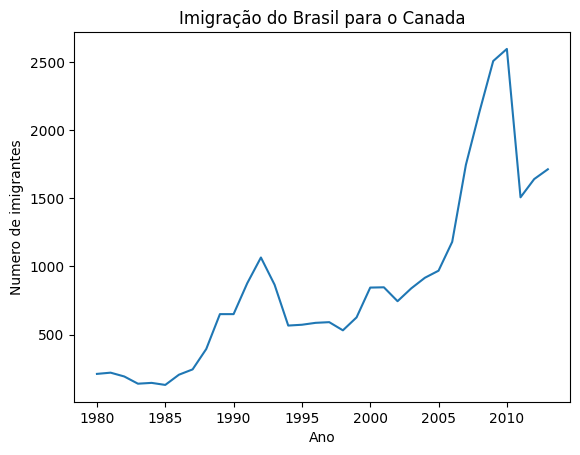

In [14]:
plt.plot(dados_brasil['ano'], dados_brasil['imigrantes'])
plt.title('Imigração do Brasil para o Canada')
plt.xlabel('Ano')
plt.ylabel('Numero de imigrantes')
plt.xticks(['1980','1985','1990', '1995', '2000', '2005', '2010'])
plt.show()

## Analisando a Argentina x Brasil

In [15]:
df_comparacao = df.loc[['Brasil', 'Argentina'], anos].T
df_comparacao.head()

País,Brasil,Argentina
1980,211,368
1981,220,426
1982,192,626
1983,139,241
1984,145,237


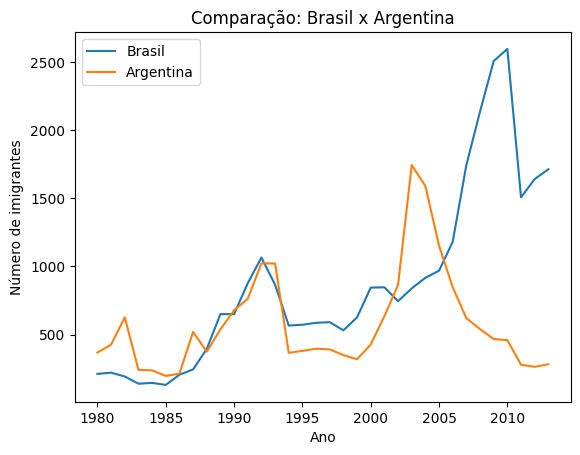

In [16]:
plt.plot(df_comparacao.index, df_comparacao['Brasil'])
plt.plot(df_comparacao.index, df_comparacao['Argentina'])
plt.xlabel('Ano')
plt.ylabel('Número de imigrantes')
plt.legend(['Brasil', 'Argentina'])
plt.title('Comparação: Brasil x Argentina')
plt.xticks(['1980','1985','1990', '1995', '2000', '2005', '2010'])
plt.show()

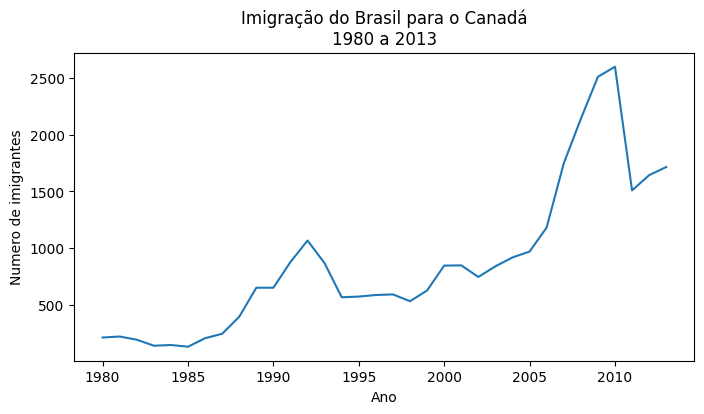

In [23]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(dados_brasil['ano'], dados_brasil['imigrantes'])
ax.set_title('Imigração do Brasil para o Canadá\n1980 a 2013')
ax.set_xlabel('Ano')
ax.set_ylabel('Numero de imigrantes')
ax.xaxis.set_major_locator(plt.MultipleLocator(5))
plt.show()

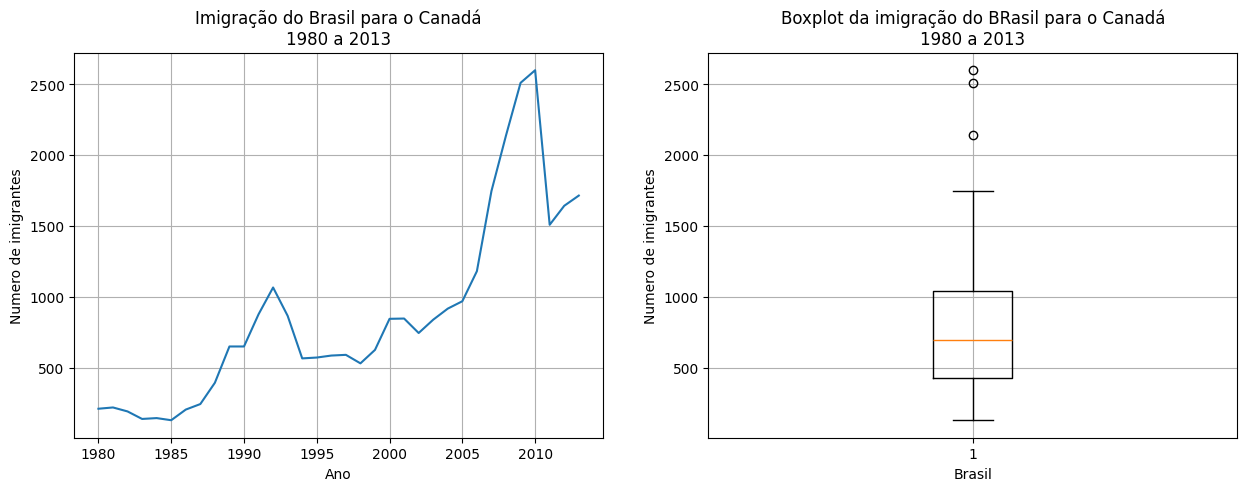

In [30]:
fig, axs = plt.subplots(1,2, figsize=(15,5))

axs[0].plot(dados_brasil['ano'], dados_brasil['imigrantes'])
axs[0].set_title('Imigração do Brasil para o Canadá\n1980 a 2013')
axs[0].set_xlabel('Ano')
axs[0].set_ylabel('Numero de imigrantes')
axs[0].xaxis.set_major_locator(plt.MultipleLocator(5))
axs[0].grid()

axs[1].boxplot(dados_brasil['imigrantes'])
axs[1].set_title('Boxplot da imigração do BRasil para o Canadá\n1980 a 2013')
axs[1].set_xlabel('Brasil')
axs[1].set_ylabel('Numero de imigrantes')
axs[1].grid()

plt.show()

In [31]:
dados_brasil.describe()

,imigrantes
count,34.000000
mean,872.323529
std,663.401232
min,130.000000
25%,428.250000
50%,697.500000
75%,1041.750000
max,2598.000000


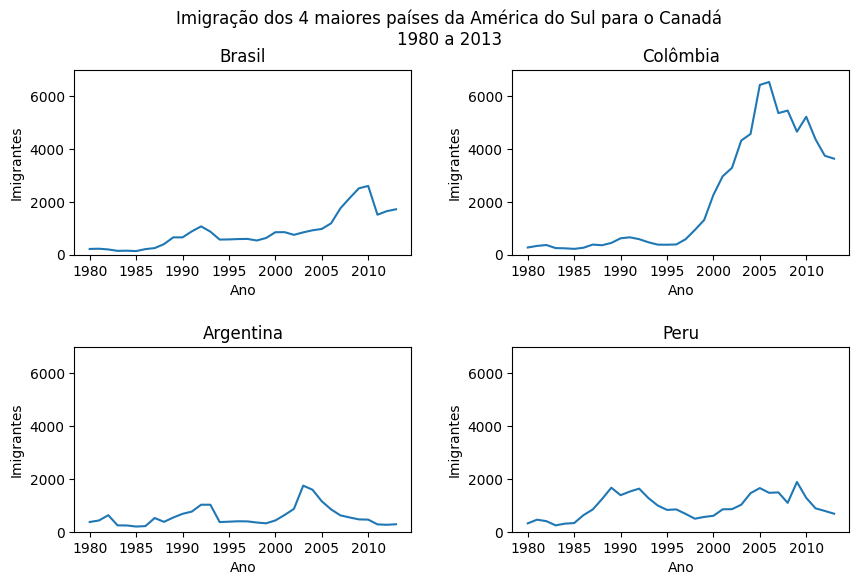

In [43]:
fig, axs = plt.subplots(2,2, figsize=(10,6))
fig.subplots_adjust(hspace= 0.5, wspace=0.3)
fig.suptitle('Imigração dos 4 maiores países da América do Sul para o Canadá\n1980 a 2013')

axs[0,0].plot(df.loc['Brasil', anos])
axs[0,0].set_title('Brasil')

axs[0,1].plot(df.loc['Colômbia', anos])
axs[0,1].set_title('Colômbia')

axs[1,0].plot(df.loc['Argentina', anos])
axs[1,0].set_title('Argentina')

axs[1,1].plot(df.loc['Peru', anos])
axs[1,1].set_title('Peru')

for ax in axs.flat:
    ax.xaxis.set_major_locator(plt.MultipleLocator(5))
    
for ax in axs.flat:
    ax.set_xlabel('Ano')
    ax.set_ylabel('Imigrantes')
    
ymin = 0
ymax = 7000

for ax in axs.ravel():
    ax.set_ylim(ymin, ymax)
    


plt.show()